# Dev Walkthrough

A running notebook that grows one section per build step. Each section exercises the code added in that step and shows its output, so you can review behaviour interactively alongside the formal `pytest` suite.

Run top-to-bottom (Kernel → Restart & Run All) after each step. Sections are appended as the library is built out.

## Scaffold + packaging

Confirms the package imports, the shared `CausalEstimate` result type works, and the numerical helpers behave.

In [1]:
import causal
from causal import CausalEstimate
from causal.utils import logit, standardized_mean_difference, normal_confidence_interval

print("causal version:", causal.__version__)
print("public exports:", causal.__all__)

causal version: 0.1.0
public exports: ['__version__', 'CausalEstimate', 'MatchingResult', 'ParallelTrendsTest', 'EventStudyResult', 'PlaceboTestResult', 'RosenbaumResult', 'EValueResult']


In [2]:
# Construct a CausalEstimate and view its summary (every estimator will return one of these)
est = CausalEstimate(
    method="example",
    estimate=0.05,
    std_error=0.012,
    confidence_interval=(0.026, 0.074),
    p_value=3.2e-5,
    n_treated=480,
    n_control=520,
    assumptions=["no unmeasured confounding", "correct outcome model"],
)
print(est.summary())

Method:   example
Estimate: 0.0500 (SE 0.0120)
95% CI:   [0.0260, 0.0740]
p-value:  3.2e-05
N:        480 treated, 520 control
Assumptions:
  - no unmeasured confounding
  - correct outcome model


In [3]:
# Numerical helpers
import numpy as np

print("logit(0.5)        =", logit([0.5])[0])
print("logit(0.1,0.5,0.9)=", np.round(logit([0.1, 0.5, 0.9]), 4))

treated = [3.1, 2.8, 3.4, 3.0, 2.9]
control = [2.1, 1.9, 2.4, 2.0, 1.8]
print("SMD (treated vs control) =", round(standardized_mean_difference(treated, control), 4))
print("95% CI for estimate 0.05 (SE 0.012) =", tuple(round(x, 4) for x in normal_confidence_interval(0.05, 0.012)))

logit(0.5)        = 0.0
logit(0.1,0.5,0.9)= [-2.1972  0.      2.1972]
SMD (treated vs control) = 4.3437
95% CI for estimate 0.05 (SE 0.012) = (np.float64(0.0265), np.float64(0.0735))


## Synthetic data generators

Three scenarios that the estimators will be validated against:

* `simulate_rct` — clean randomized trial (gold standard).
* `simulate_observational` — confounding by indication; the naive comparison is biased.
* `simulate_panel` — long-format panel with parallel pre-trends (for DiD & synthetic control).

In [4]:
import matplotlib.pyplot as plt
from causal.data.simulate import simulate_rct, simulate_observational, simulate_panel

rct = simulate_rct(n=8000, treatment_effect=0.05, seed=42)
obs = simulate_observational(n=8000, treatment_effect=0.05, confounding_strength=2.0, seed=42)
rct.head()

,age,severity,comorbidities,treatment,outcome
0,64.570756,5.667205,1.0,1,0
1,44.400238,7.472686,1.0,0,0
2,71.256768,7.431659,4.0,1,0
3,74.108471,4.098086,3.0,0,0
4,30.734472,5.388035,1.0,1,0


In [5]:
def naive_diff(df):
    return df.loc[df.treatment == 1, 'outcome'].mean() - df.loc[df.treatment == 0, 'outcome'].mean()

TRUTH = 0.05
print(f"True effect:                  {TRUTH:+.4f}")
print(f"RCT naive estimate:           {naive_diff(rct):+.4f}  (unbiased — randomization works)")
print(f"Observational naive estimate: {naive_diff(obs):+.4f}  (BIASED — confounding by indication)")
print()
print("Mean severity by group (observational):")
print(obs.groupby('treatment')['severity'].mean().round(2))

True effect:                  +0.0500
RCT naive estimate:           +0.0479  (unbiased — randomization works)
Observational naive estimate: +0.1143  (BIASED — confounding by indication)

Mean severity by group (observational):
treatment
0    3.79
1    6.19
Name: severity, dtype: float64


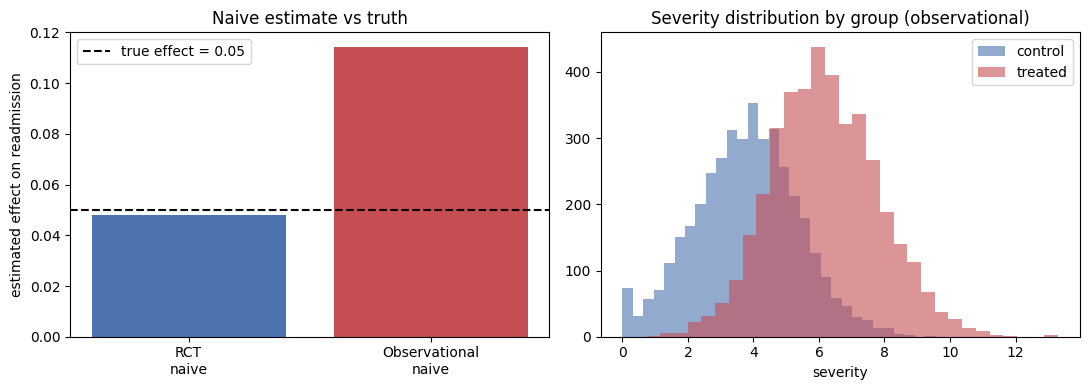

In [6]:
# Visualize: why the observational naive estimate is biased
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) naive estimates vs truth
labels = ['RCT\nnaive', 'Observational\nnaive']
vals = [naive_diff(rct), naive_diff(obs)]
axes[0].bar(labels, vals, color=['#4c72b0', '#c44e52'])
axes[0].axhline(TRUTH, color='k', ls='--', label=f'true effect = {TRUTH}')
axes[0].set_title('Naive estimate vs truth')
axes[0].set_ylabel('estimated effect on readmission')
axes[0].legend()

# (b) severity imbalance drives the bias
for t, color in [(0, '#4c72b0'), (1, '#c44e52')]:
    axes[1].hist(obs.loc[obs.treatment == t, 'severity'], bins=30, alpha=0.6,
                 color=color, label=('treated' if t else 'control'))
axes[1].set_title('Severity distribution by group (observational)')
axes[1].set_xlabel('severity')
axes[1].legend()
fig.tight_layout()
plt.show()

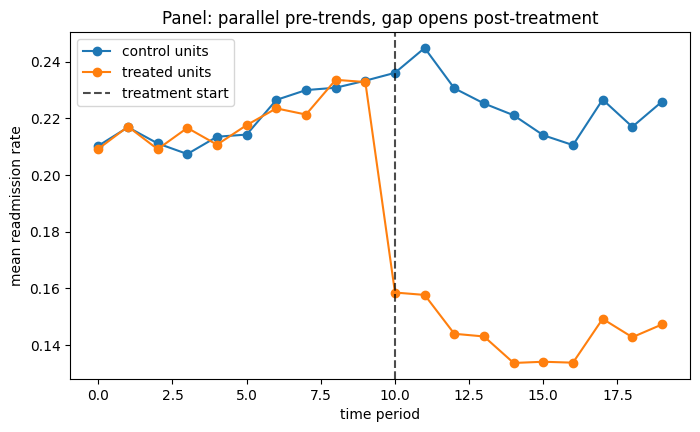

Panel shape: (800, 4) | treated units: 8


In [7]:
# Panel data: parallel pre-trends, then a treatment effect after period 10
panel = simulate_panel(n_units=40, n_periods=20, treatment_period=10,
                       treatment_effect=-0.08, n_treated_units=8, seed=42)
means = panel.groupby(['time', 'treatment'])['outcome'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(means.index, means[0], marker='o', label='control units')
ax.plot(means.index, means[1], marker='o', label='treated units')
ax.axvline(10, color='k', ls='--', alpha=0.7, label='treatment start')
ax.set_title('Panel: parallel pre-trends, gap opens post-treatment')
ax.set_xlabel('time period'); ax.set_ylabel('mean readmission rate'); ax.legend()
plt.show()

print('Panel shape:', panel.shape, '| treated units:', panel.loc[panel.treatment == 1, 'unit'].nunique())

## Propensity score matching & IPW

Build a valid comparison group from the confounded observational data:

1. **Overlap check** — propensity scores for treated vs control must overlap (common support).
2. **Matching** — nearest-neighbour within a caliper; the love plot shows balance improving (SMD below 0.1).
3. **IPW** — reweight the sample as a robustness check.

Both methods should pull the biased naive estimate (~+0.11) back toward the true **+0.05**.

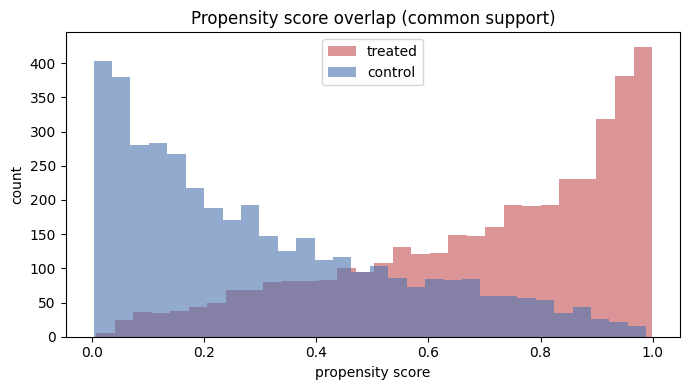

In [8]:
from causal.matching import (
    PropensityScoreModel, PropensityScoreMatching,
    InverseProbabilityWeighting, plot_balance,
)

# Reuse the confounded observational data from the previous section.
cov_cols = ['age', 'severity', 'comorbidities']
X, t, y = obs[cov_cols], obs['treatment'], obs['outcome']

# Overlap (common support) diagnostic — distributions must overlap to match.
ps_model = PropensityScoreModel(X, t).fit()
ps_model.plot_overlap()
plt.show()

Method:   Propensity score matching (ATT)
Estimate: 0.0295 (SE 0.0142)
95% CI:   [0.0017, 0.0574]
p-value:  0.0378
N:        1762 treated, 1762 control
Assumptions:
  - Conditional ignorability (no unmeasured confounders)
  - Common support / overlap between treated and control
  - Correctly specified propensity model

Matched 1762/3988 treated units (unmatched 2226)


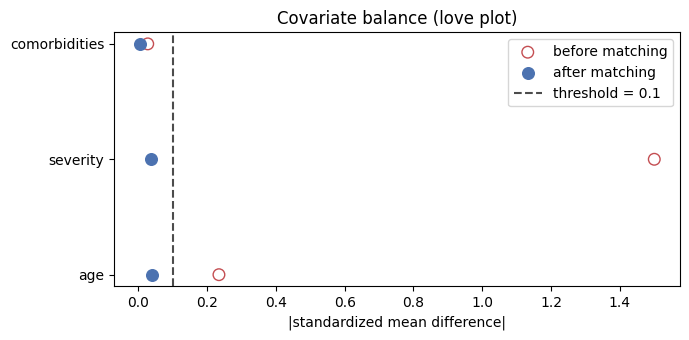

In [9]:
# Match within a caliper, estimate the ATT, and check covariate balance (love plot)
psm = PropensityScoreMatching(X, t, y, caliper=0.05)
result = psm.match()
att = psm.estimate_att()
print(att.summary())
print(f"\nMatched {result.n_matched}/{result.n_treated} treated units (unmatched {result.n_unmatched})")

plot_balance(result)
plt.show()

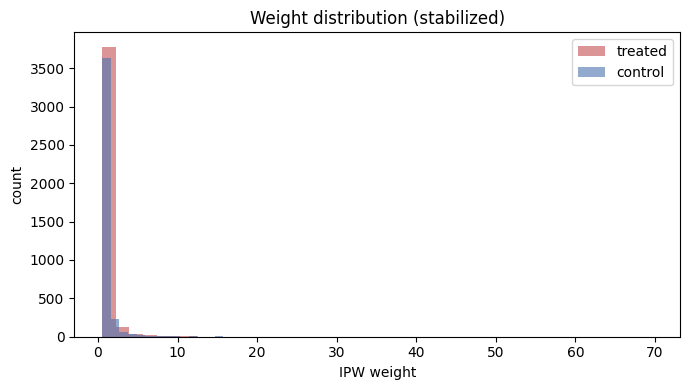

Effect on 30-day readmission (truth = +0.0500):
  naive difference : +0.1143   <- biased by confounding
  PSM (ATT)        : +0.0295   CI [+0.0017, +0.0574]
  IPW (ATE)        : +0.0693   CI [+0.0319, +0.1068]


In [10]:
# IPW as a robustness check, then compare all estimates to the truth
ipw = InverseProbabilityWeighting(X, t, y)
ate = ipw.estimate_ate(stabilized=True)
ipw.plot_weight_distribution()
plt.show()

print('Effect on 30-day readmission (truth = +0.0500):')
print(f"  naive difference : {naive_diff(obs):+.4f}   <- biased by confounding")
print(f"  PSM (ATT)        : {att.estimate:+.4f}   CI [{att.confidence_interval[0]:+.4f}, {att.confidence_interval[1]:+.4f}]")
print(f"  IPW (ATE)        : {ate.estimate:+.4f}   CI [{ate.confidence_interval[0]:+.4f}, {ate.confidence_interval[1]:+.4f}]")